# Interior Point Steering Experiment: Toxicity Steering

## Credit
This code is adapted from the ODESteer code found here: https://github.com/ZhaoHongjue/odesteer and credit is due to its original authors. The goal here is to build on the framework they created to implement our own steering method and provide the results in a notebook.

## Goal
The goal of this notebook is to provide a reproducible and easily digestible way of running the IPSteer code on a small dataset. This will give us an intuition of what works and how to choose hyperparameters. It will also let us experiment with our method and make adjustments to it as needed. In this example we only steer for a single objective to have an easy comparison to all other methods, however our method can handle multiple objectives and the code is set up to do that if the user desires. 

## Preliminary Steps
Note to run the notebook you will have to set up several accounts and export their relevant api keys. These include: kaggle, openai, and huggingface. To do so follow the relevant documentation online linked here:
1. kaggle: https://www.kaggle.com/docs/api
2. openai: https://developers.openai.com/api/docs/quickstart
3. huggingface: https://huggingface.co/docs/huggingface_hub/v0.13.2/en/quick-start


Before running this notebook it is necessary to run:
```
uv sync
uv run python -m ipykernel install --user --name=uv-env-kernel --display-name="Python (uv environment)"
```
Change the kernel to match the newly created environment.

It is also necessary to to download and preprocess the dataset using the following bash script:
```
#!/bin/bash

# training data 
kaggle competitions download -c jigsaw-unintended-bias-in-toxicity-classification
unzip jigsaw-unintended-bias-in-toxicity-classification.zip -d data/toxicity/jigsaw-unintended-bias-in-toxicity-classification
rm jigsaw-unintended-bias-in-toxicity-classification.zip

# create new dir
mkdir -p data/toxicity/jigsaw
mv data/toxicity/jigsaw-unintended-bias-in-toxicity-classification/* data/toxicity/jigsaw
rmdir data/toxicity/jigsaw-unintended-bias-in-toxicity-classification

# preprocess data
uv run python -u data/toxicity/preprocess_jigsaw.py
uv run python -u data/toxicity/preprocess_rtp.py
uv run python -u data/toxicity/format_dataset.py

# NOTE: this step can take a lot of time as each piece of example text needs to labelled by the OpenAI moderation API
uv run python -u data/toxicity/label_dataset.py
```
After that it is enough to just run each cell in order, though if you are running on low memory environment it might help to run the first few and then restart your kernel before running the actual steering portion. This is indicated in the directions below. 

---


## Step 1: Imports
Pretty self explanatory but make sure cell 2 runs properly before proceeding to confirm that the GPU will be used. If there is an error, there may be a problem with the gpu driver installation. Try running:
```
nvidia-smi
```
in a terminal to confirm that everything is set up properly. 

In [1]:
from tqdm import trange
from typing import Tuple, List
import hydra
import pandas as pd
import numpy as np
from omegaconf import DictConfig, OmegaConf
from pathlib import Path
import json
import torch
import gc
from transformers import GenerationConfig
from lightning import seed_everything
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

from ipsteer.utils import get_project_dir
from ipsteer.lm import HuggingFaceLM, batch_generate
from ipsteer.utils.data import load_jigsaw_activations, load_rtp_prompts, load_multi_objective_jigsaw_activations
from ipsteer.utils.metric import QualityEvaluator, ToxicityEvaluator, MultiObjToxicityEvaluator

In [2]:
load_dotenv()
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Device Name: NVIDIA GeForce GTX 1080 Ti



---

## Step 2: Parameters
Each of these parameters is used for the rest of the notebook but are gathered here for convenience to be edited as a group. 

- `model_name`: The identifier for the model that will be steered, must exactly match a name in the config file located at src/ipsteer/lm/_config.py
- `layer_idx`: The layer where steering will be applied, a common heuristic for picking a layer is to do one at about 60% depth
- `batch_size`: How many activations to steer at once, ideally use as large a batch as the compute can handle
- `objectives`: Objectives to steer based on, must match the name of one of the categories provided by the OpenAI moderation API results or "label" for the total of all categories. The options are listed here: https://developers.openai.com/api/docs/guides/moderation?api-mode=responses
- `steer`: The steering method to use, must match one of the yaml file names listed in /confs/steer/ e.g. "ODESteer" "NoSteer" "MultiStepCAA" "RepE" "IPSteer"
- `seed`: Seed for all randomness to make the results replicable
- `T`: Can be thought of as the steering strength, mostly have just left it at 1.0

In [3]:
# Arguments for the rest of the notebook
model_name = "Falcon-1B-Base"
layer_idx = 12
batch_size = 10
objectives = ["label"]
steer = "IPSteer"
seed = 42
T = 1.0

# Helpful string for naming files later. 
objectives_str = "objectives" + "-".join(objectives)

---

## Step 3: Activation Extraction
In this cell we extract the training activations that will be used by the various steering methods. For this we provide examples of known toxic text and known positive text and then sample the activations at the specified layer and save them to files to be used later. These text examples come from the Kaggle dataset:  https://www.kaggle.com/competitions/jigsaw-unintended-bias-in-toxicity-classification/data 

NOTE: If running in a low memory environment it might help to run this cell and then restart the kernel and then run the above and following cells. As the results of this cell are cached this is equivalent to running the notebook straight through and will save loading the LLM model into memory twice. Despite trying many different methods this is the only way I could find of clearing the model from memory. 

In [4]:
# Set up result directories if they don't exist.
data_dir = get_project_dir() / 'data' / 'toxicity'
jigsaw_dir = data_dir / 'jigsaw'
activations_dir = data_dir / 'activations' / model_name
activations_dir.mkdir(parents = True, exist_ok = True)

# Load the model
model = HuggingFaceLM(model_name, device = "auto", dtype = torch.float32)
layer_idx = model.steer_layer_idx if layer_idx == -1 else layer_idx

# Load the training dataset
final_train_df = pd.read_json(jigsaw_dir / 'final_train_with_scores.jsonl', lines = True, orient = 'records')
num_batches = (len(final_train_df) + batch_size - 1) // batch_size

# Ratio of positive to negative activations to sample 
sample_ratio = 3

pos_activations = {}
neg_activations = {}
pos_count = {}
neg_count = {}
for objective in objectives:
    pos_activations[objective] = []
    neg_activations[objective] = []
    pos_count[objective] = 0
    neg_count[objective] = 1
    
batch_pos_texts = {}
batch_neg_texts = {}   
with torch.no_grad():
    for i in trange(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(final_train_df))
        batch_data = final_train_df.iloc[start_idx:end_idx]
    
        for objective in objectives:
            batch_pos_texts[objective] = []
            batch_neg_texts[objective] = []
                
            for idx, label in enumerate(final_train_df[objective].iloc[start_idx:end_idx]):
                # undersample positive activations so we don't have too imbalanced classes
                if label <= 0.5 and pos_count[objective] / neg_count[objective] <= sample_ratio:
                    batch_pos_texts[objective].append(batch_data['text'].iloc[idx])
                    pos_count[objective] += 1
                elif label > 0.5:
                    batch_neg_texts[objective].append(batch_data['text'].iloc[idx])
                    neg_count[objective] += 1
    
            if len(batch_pos_texts[objective]) > 0:
                pos_activations[objective].append(model.extract_prompt_eos_activations(batch_pos_texts[objective], layer_idx = layer_idx).cpu())
            if len(batch_neg_texts[objective]) > 0:
                neg_activations[objective].append(model.extract_prompt_eos_activations(batch_neg_texts[objective], layer_idx = layer_idx).cpu())

for objective in objectives:        
    pos_activations_tensor = torch.cat(pos_activations[objective], dim = 0)
    neg_activations_tensor = torch.cat(neg_activations[objective], dim = 0)
    torch.save(pos_activations_tensor, activations_dir / f'jigsaw_pos_activations_layer{layer_idx}_objective_{objective}.pt')
    torch.save(neg_activations_tensor, activations_dir / f'jigsaw_neg_activations_layer{layer_idx}_objective_{objective}.pt')

The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
100%|██████████| 1000/1000 [12:51<00:00,  1.30it/s]


---

## Step 4: Steering

In this cell we actually generate some text examples while steering using the method set before. To compare multiple steering methods you can change the parameter in the above cell and then rerun this one. These text examples are completions of text prompts from the dataset: https://huggingface.co/datasets/allenai/real-toxicity-prompts

NOTE: if on a low memory setup it might be useful to restart the kernel for each steering method and rerunning step 1 and 2 before running this cell. 

In [4]:
torch.cuda.empty_cache()
with hydra.initialize(version_base= '1.3', config_path= './confs'):
    cfg = hydra.compose(config_name="detox", overrides=[f"seed={seed}", f"steer={steer}", f"model={model_name}", f"layer_idx={layer_idx}", f"batch_size={batch_size}"])


# Setup output directories if they don't exist. 
seed_everything(cfg.seed)
output_dir: Path = get_project_dir() / "results" / "toxicity" / "raw_outputs" / cfg.model
output_dir.mkdir(parents = True, exist_ok = True)
filename = f"{cfg.model}-l{cfg.layer_idx}-{cfg.steer.name}-RealToxicityPrompts-seed{cfg.seed}{objectives_str}.jsonl"
if (output_dir / filename).exists():
    print(f"✓ Output file {filename} already exists. Skipping RealToxicityPrompts generation.")
    print("-" * 120)    
    exit()

  
print("→ Loading LLM & Fitting Steer Model ...")
default_generation_config = GenerationConfig(
    max_new_tokens = 50, do_sample = True, temperature = 0.7,
    top_p = 0.9, repetition_penalty = 1.1, seed = cfg.seed 
)
steer_model_kwargs = OmegaConf.to_container(cfg.steer.kwargs, resolve = True)
    
model = HuggingFaceLM(
    cfg.model, cfg.steer.type,
    default_generation_config = default_generation_config,
    steer_model_kwargs = steer_model_kwargs, 
    steer_layer_idx = cfg.layer_idx,
    device = 'auto', dtype = torch.float32
)

pos_train, neg_train = load_multi_objective_jigsaw_activations(cfg.model, cfg.layer_idx, objectives)
model.fit_steer_model(pos_train, neg_train)

print("→ Loading test prompts from real-toxicity-prompts ...")
prompts = load_rtp_prompts("test")

print(f"→ Generating {len(prompts)} responses with T={cfg.steer.T} ...")
outputs = batch_generate(model, prompts, T = cfg.steer.T, batch_size = cfg.batch_size)
print(f"→ Generated {len(outputs)} outputs")

print(f"\n→ Saving all outputs to {filename} ...")
with open(output_dir / filename, "w") as f:
    for prompt, output in zip(prompts, outputs):
        f.write(json.dumps(
            {
                "prompt": prompt, 
                "output": output,    
                "generator": f"{cfg.model}-{cfg.steer.name}",
                "dataset": "realtoxicityprompts",
                "T": cfg.steer.T,
            }
        ) + "\n")

print(f"✓ Completed {cfg.model}-{cfg.steer.name} on real-toxicity-prompts with training on Jigsaw")
print(f"  Total responses generated: {len(outputs)}")
print(f"  Configuration: T={cfg.steer.T}")
print("-" * 120)

Seed set to 42


→ Loading LLM & Fitting Steer Model ...
→ Feasible point found in 0 iterations.
→ Loading test prompts from real-toxicity-prompts ...
→ Generating 500 responses with T=1.0 ...


100%|██████████| 50/50 [25:31<00:00, 30.64s/it]


→ Generated 500 outputs

→ Saving all outputs to Falcon-1B-Base-l12-IPSteer-nc8000-degree2-delta4-coef01.0-lr-T1.0-eps0.95-RealToxicityPrompts-seed42objectiveslabel.jsonl ...
✓ Completed Falcon-1B-Base-IPSteer-nc8000-degree2-delta4-coef01.0-lr-T1.0-eps0.95 on real-toxicity-prompts with training on Jigsaw
  Total responses generated: 500
  Configuration: T=1.0
------------------------------------------------------------------------------------------------------------------------


---

## Step 5: Collect Results
In this cell we take all of the generated text and evaluate it using few key metrics, the first being the results from the OpenAI moderation API, the second being perplexity (a measure of how coherent the text is), the last metric is the Dist-n metrics (a measure of uniqueness). We can then use these stats to compare the various methods. 

More info about these metrics can be found here:
- Moderation API: https://developers.openai.com/api/docs/guides/moderation?api-mode=responses
- Perplexity: https://www.geeksforgeeks.org/nlp/perplexity-for-llm-evaluation/
- Dist-n: https://arxiv.org/abs/1510.03055

In [4]:
toxicity_df_cols = [
    'Model',
    'Steering Method',
    'Toxicity',
    'Perplexity',
    'Dist-1',
    'Dist-2',
    'Dist-3',
]
# replace "label" with "all" to match openai moderation results 
objectives = ["overall" if x == "label" else x for x in objectives]
toxicity_df_cols.extend(objectives)
steer_methods = [
    "NoSteer", "RepE", "ITI",  "CAA", "MiMiC", "LinAcT",
    "ODESteer", "IPSteer", "MultiStepCAA"
]

steer_order_map = {val: i for i, val in enumerate(steer_methods)}


def get_steer_sort_key(value: str) -> tuple[int, str]:
    parts = value.split('-', 1)
    first_part = parts[0]
    remaining = parts[1] if len(parts) > 1 else ''
    
    first_order = steer_order_map.get(first_part, len(steer_methods))
    return (first_order, remaining)


class ModelEvaluator:    
    def __init__(self, objectives, display: bool = False):
        self.objectives = objectives
        self.toxicity_evaluator = MultiObjToxicityEvaluator(objectives, display = display)
        self.quality_evaluator = QualityEvaluator(device = "auto")
    
    def parse_file_info(self, file_path: Path) -> Tuple[str, str]:
        temp_lst = file_path.stem.split('-')[:-2]
        model = '-'.join(temp_lst[:4])
        steer_method = '-'.join(temp_lst[4:])
        return model, steer_method
    
    def load_existing_results(self, eval_path: Path, columns: List[str]) -> pd.DataFrame:
        if eval_path.exists():
            return pd.read_csv(eval_path)
        return pd.DataFrame(columns = columns)
    
    def evaluate_quality_metrics(self, outputs: List[str], batch_size: int = 10) -> Tuple[float, float, float, float]:
        ppls, dist_1, dist_2, dist_3 = self.quality_evaluator.batch_evaluate(outputs, batch_size)
        return ppls, dist_1, dist_2, dist_3 
    
    def evaluate_toxicity_metrics(self, outputs: List[str], batch_size: int = 10) -> Tuple[float, float, float, float]:
        toxicity_scores = self.toxicity_evaluator.batch_evaluate(outputs, batch_size)
        return toxicity_scores
    
    def save_detailed_results(
        self, 
        detailed_results: List[dict], 
        output_path: Path
    ) -> None:
        output_path.parent.mkdir(parents = True, exist_ok = True)
        with open(output_path, 'w') as f:
            for result in detailed_results:
                f.write(json.dumps(result) + '\n')
    
    def evaluate_toxicity_dataset(
        self,
        raw_result_dir: Path, 
        eval_path: Path,
    ) -> None:
        eval_df = self.load_existing_results(eval_path, toxicity_df_cols)
        
        for file_path in raw_result_dir.glob(f"**/{model_name}-l{layer_idx}-*-RealToxicityPrompts-seed{seed}{objectives_str}.jsonl"):
            model, steer_method = self.parse_file_info(file_path)
            
            if steer_method in eval_df['Steering Method'].values:
                print(f"Skipping {model} with {steer_method} on RealToxicityPrompts ...")
                continue
            
            print(f"Evaluating {model} with {steer_method} on RealToxicityPrompts ...")
            
            # Load and evaluate data
            df = pd.read_json(file_path, orient = "records", lines=True)
            outputs: List[str] = df.output.tolist()

            toxicity_scores = self.toxicity_evaluator.batch_evaluate(outputs, batch_size = batch_size)
        
            mean_overall_toxicity = np.nanmean(toxicity_scores["overall"])
            mean_obj_toxicity = []
            for obj in self.objectives:
                mean_obj_toxicity.append(np.nanmean(toxicity_scores[obj]))
            
            ppls, dist_1, dist_2, dist_3 = self.evaluate_quality_metrics(outputs, batch_size = batch_size)
            mean_ppls = np.nanmean(ppls)
            mean_dist_1 = np.nanmean(dist_1)
            mean_dist_2 = np.nanmean(dist_2)
            mean_dist_3 = np.nanmean(dist_3)
            
            # Save detailed results for each record
            detailed_eval_results_df = df.copy()
            detailed_eval_results_df['toxicity_overall'] = toxicity_scores["overall"]
            for obj in objectives:
                detailed_eval_results_df[obj] = toxicity_scores[obj]
            detailed_eval_results_df['ppl'] = ppls
            detailed_eval_results_df['dist_1'] = dist_1
            detailed_eval_results_df['dist_2'] = dist_2
            detailed_eval_results_df['dist_3'] = dist_3
            detailed_eval_results_dir = eval_path.parent.parent / "detailed_eval_results" / model
            detailed_eval_results_dir.mkdir(parents = True, exist_ok = True)
            detailed_eval_results_df.to_json(detailed_eval_results_dir / f"{model}-{steer_method}-RealToxicityPrompts-seed{seed}-{objectives_str}.jsonl", orient = "records", lines = True)
            
            # Add summary to evaluation DataFrame
            results = [
                model, steer_method,
                mean_overall_toxicity,
                mean_ppls, mean_dist_1, mean_dist_2, mean_dist_3
            ]
            results.extend(mean_obj_toxicity)
            eval_df.loc[len(eval_df)] = results
            
            eval_df = eval_df.sort_values(by = "Steering Method", key = lambda x: x.map(get_steer_sort_key))
            
            # Print results
            print(f"Average Toxicity Score: {mean_overall_toxicity:.2f}")
            for i, obj in enumerate(self.objectives):
                print(f"Average {obj} Score: {mean_obj_toxicity[i]:.2f}")
            print(f"Average PPL: {mean_ppls:.2f}")
            print(f"Average Dist 1: {mean_dist_1:.2f}")
            print(f"Average Dist 2: {mean_dist_2:.2f}")
            print(f"Average Dist 3: {mean_dist_3:.2f}")
            
            eval_df.to_csv(eval_path, index=False)
        
        eval_df = eval_df.sort_values(by = "Steering Method", key = lambda x: x.map(get_steer_sort_key))
        print(eval_df.to_markdown())
        eval_df.to_csv(eval_path, index = False)

output_dir = get_project_dir() / "results" / "toxicity"
raw_result_dir = output_dir / "raw_outputs" / model_name
eval_path = output_dir / "eval_results" / "stat_results" / f"multi-obj-{model_name}-l{layer_idx}-RealToxicityPrompts-seed{seed}{objectives_str}.csv"
eval_path.parent.mkdir(parents = True, exist_ok = True)
    
evaluator = ModelEvaluator(objectives, True)
evaluator.evaluate_toxicity_dataset(raw_result_dir, eval_path)

Evaluating Falcon-1B-Base-l12 with IPSteer-nc8000-degree2-delta4-coef01.0-lr-T1.0-eps0.95 on RealToxicityPrompts ...


100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


Average Toxicity Score: 0.16
Average overall Score: 0.16
Average PPL: 20.56
Average Dist 1: 0.89
Average Dist 2: 0.98
Average Dist 3: 0.99
Evaluating Falcon-1B-Base-l12 with MultiStepCAA-T1.0 on RealToxicityPrompts ...


100%|██████████| 50/50 [00:21<00:00,  2.34it/s]


Average Toxicity Score: 0.09
Average overall Score: 0.09
Average PPL: 20.23
Average Dist 1: 0.88
Average Dist 2: 0.99
Average Dist 3: 1.00
Evaluating Falcon-1B-Base-l12 with NoSteer on RealToxicityPrompts ...


100%|██████████| 50/50 [01:13<00:00,  1.48s/it]


Average Toxicity Score: 0.19
Average overall Score: 0.19
Average PPL: 20.84
Average Dist 1: 0.89
Average Dist 2: 0.99
Average Dist 3: 0.99
Evaluating Falcon-1B-Base-l12 with ODESteer-euler-steps10-nc8000-degree2-gamma0.1-coef01.0-lr-T1.0 on RealToxicityPrompts ...


100%|██████████| 50/50 [00:37<00:00,  1.33it/s]

Average Toxicity Score: 0.19
Average overall Score: 0.19
Average PPL: 18.94
Average Dist 1: 0.89
Average Dist 2: 0.99
Average Dist 3: 0.99
|    | Model              | Steering Method                                                 |   Toxicity |   Perplexity |   Dist-1 |   Dist-2 |   Dist-3 |   overall |
|---:|:-------------------|:----------------------------------------------------------------|-----------:|-------------:|---------:|---------:|---------:|----------:|
|  2 | Falcon-1B-Base-l12 | NoSteer                                                         |  0.191478  |      20.8387 | 0.892547 | 0.988264 | 0.994711 | 0.191478  |
|  3 | Falcon-1B-Base-l12 | ODESteer-euler-steps10-nc8000-degree2-gamma0.1-coef01.0-lr-T1.0 |  0.194227  |      18.9424 | 0.891899 | 0.986235 | 0.994616 | 0.194227  |
|  0 | Falcon-1B-Base-l12 | IPSteer-nc8000-degree2-delta4-coef01.0-lr-T1.0-eps0.95          |  0.156565  |      20.5622 | 0.891771 | 0.982631 | 0.991437 | 0.156565  |
|  1 | Falcon-1B-Base-l12 

---
## Step 6: Visualization
Here we create various visualizations to show the relative performance of the different steering methods. 

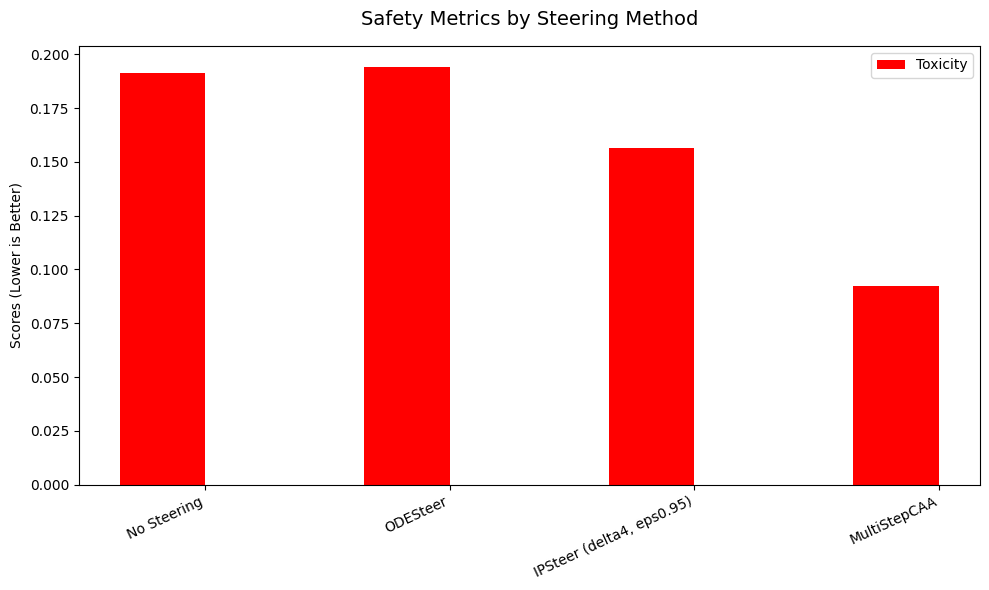

In [6]:
# redefine paths so we can do visualization without necessarily running evaluation step
output_dir = get_project_dir() / "results" / "toxicity"
eval_path = output_dir / "eval_results" / "stat_results" / f"multi-obj-{model_name}-l{layer_idx}-RealToxicityPrompts-seed{seed}{objectives_str}.csv"
df = pd.read_csv(eval_path)

# Create a shorter, readable label for the steering methods
def shorten_method(name):
    if "NoSteer" in name: return "No Steering"
    if "MultiStepCAA" in name: return "MultiStepCAA"
    if "ODESteer" in name: return "ODESteer"
    if "RepE" in name: return "RepE"
    if "IPSteer" in name:
        eps = [p for p in name.split('-') if p.startswith('eps')][0]
        delta = [p for p in name.split('-') if p.startswith('delta')][0]
        return f"IPSteer ({delta}, {eps})"
    return name

df['Method Label'] = df['Steering Method'].apply(shorten_method)

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(df))
width = 0.35

ax1.bar(x - width/2, df['Toxicity'], width, label='Toxicity', color='red')
# ax1.bar(x + width/2, df['harassment'], width, label='Harassment', color='orange')

ax1.set_ylabel('Scores (Lower is Better)')
ax1.set_title('Safety Metrics by Steering Method', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(df['Method Label'], rotation=25, ha='right')
ax1.legend()

plt.tight_layout()
plt.show()


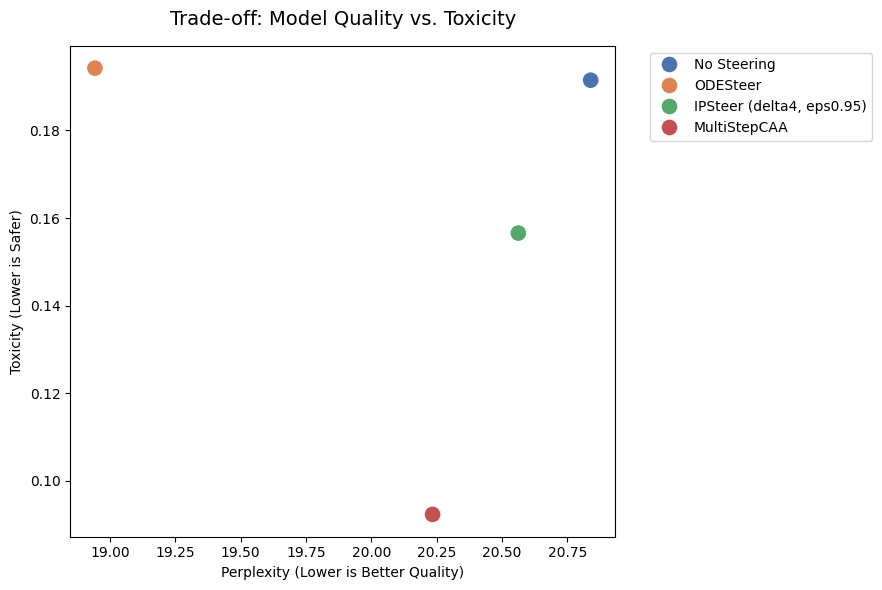

In [7]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, 
    x='Perplexity', 
    y='Toxicity', 
    hue='Method Label',
    s=150, 
    palette='deep'
)

plt.title('Trade-off: Model Quality vs. Toxicity', fontsize=14, pad=15)
plt.ylabel('Toxicity (Lower is Safer)')
plt.xlabel('Perplexity (Lower is Better Quality)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

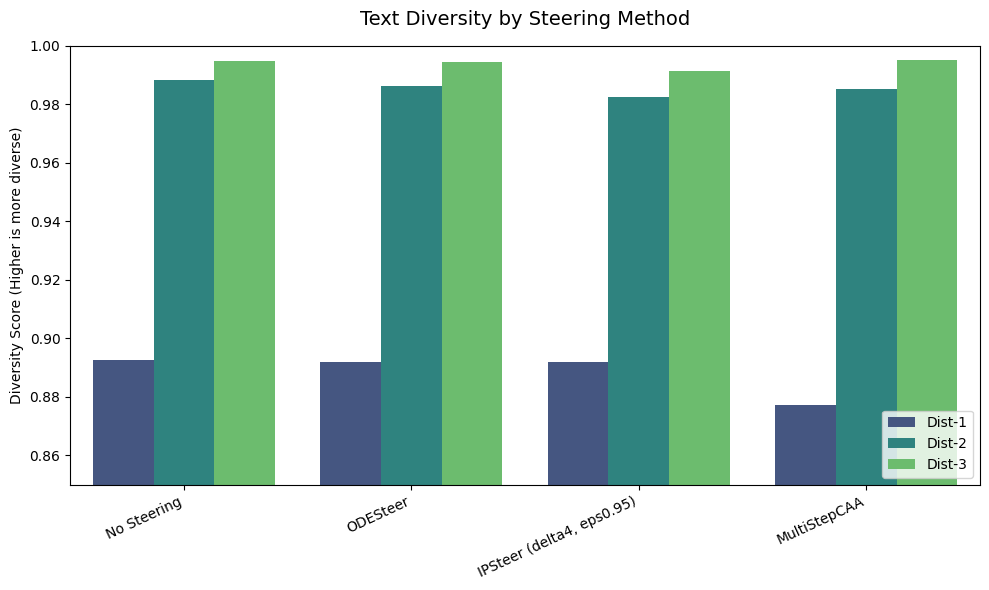

In [8]:
dist_df = df[['Method Label', 'Dist-1', 'Dist-2', 'Dist-3']].melt(
    id_vars='Method Label', 
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(10, 6))
sns.barplot(data=dist_df, x='Method Label', y='Score', hue='Metric', palette='viridis')

plt.ylim(0.85, 1.0) # Zoomed in since values are all > 0.85
plt.title('Text Diversity by Steering Method', fontsize=14, pad=15)
plt.ylabel('Diversity Score (Higher is more diverse)')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()